# Classificação de Dígitos com MNIST
Neste notebook, faremos o download do dataset MNIST diretamente do repositório no Hugging Face (formato Parquet) e processaremos as imagens embutidas usando o TensorFlow.

In [1]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from PIL import Image

# Importações do Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Download dos Dados
Baixaremos os arquivos `.parquet` originais disponibilizados pelo Yann LeCun no Hugging Face.

In [2]:
# URLs para a base de dados
url_base = "https://huggingface.co/datasets/ylecun/mnist/resolve/main/mnist/"

arquivos = {
    "treino": "train-00000-of-00001.parquet",
    "teste": "test-00000-of-00001.parquet"
}

pasta_dados = "mnist_huggingface"
os.makedirs(pasta_dados, exist_ok=True)

caminhos_locais = {}

for chave, arquivo in arquivos.items():
    caminho = os.path.join(pasta_dados, arquivo)
    caminhos_locais[chave] = caminho
    if not os.path.exists(caminho):
        print(f"Baixando {arquivo} do Hugging Face...")
        urllib.request.urlretrieve(url_base + arquivo, caminho)
        print(f"{arquivo} baixado com sucesso.")
    else:
        print(f"{arquivo} já se encontra na pasta local.")

Baixando train-00000-of-00001.parquet do Hugging Face...
train-00000-of-00001.parquet baixado com sucesso.
Baixando test-00000-of-00001.parquet do Hugging Face...
test-00000-of-00001.parquet baixado com sucesso.


## Processamento dos Arquivos Parquet
A função abaixo extrai as imagens e os rótulos. Utilizamos a biblioteca `PIL` (Pillow) e `io` para transformar os bytes brutos do DataFrame em arrays Numpy.

In [3]:
def extrair_dados_parquet(caminho):
    df = pd.read_parquet(caminho)

    # Extrai os bytes brutos utilizando list comprehension
    imagens = [
        np.array(Image.open(io.BytesIO(dado['bytes'])).convert('L'))
        for dado in df['image']
    ]

    # Adiciona a dimensão do canal (necessário para a CNN)
    X_dados = np.expand_dims(np.array(imagens), axis=-1)

    # Extrai os labels
    y_dados = df['label'].to_numpy()

    return X_dados, y_dados

X_treinamento, y_treinamento = extrair_dados_parquet(caminhos_locais['treino'])
X_validacao, y_validacao = extrair_dados_parquet(caminhos_locais['teste'])

## Normalização e One-Hot Encoding
É necessário converter os pixels para o intervalo `[0, 1]` e usar one-hot encoding nas classes.

In [4]:
# Normalizando pixels
X_treinamento_norm = X_treinamento.astype('float32') / 255.0
X_validacao_norm = X_validacao.astype('float32') / 255.0

# Convertendo rótulos
y_treinamento_cat = to_categorical(y_treinamento, num_classes=10)
y_validacao_cat = to_categorical(y_validacao, num_classes=10)

print(f"Amostras de treino: {X_treinamento_norm.shape[0]}")
print(f"Amostras de teste: {X_validacao_norm.shape[0]}")

Amostras de treino: 60000
Amostras de teste: 10000


## Arquitetura da Rede Neural Convolucional
Vamos definir um modelo Sequencial com algumas camadas de convolução, pooling e dropout para evitar overfitting.

In [5]:
modelo_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       200,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 206,922 (808.29 KB)

 Trainable params: 206,922 (808.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compilação e Treinamento
Treinaremos o modelo por 15 épocas.

In [6]:
modelo_cnn.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

historico_treino = modelo_cnn.fit(
    X_treinamento_norm, y_treinamento_cat,
    epochs=15,
    batch_size=128,
    validation_split=0.15
)

Epoch 1/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8804 - loss: 0.3877 - val_accuracy: 0.9756 - val_loss: 0.0896
Epoch 2/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9613 - loss: 0.1248 - val_accuracy: 0.9836 - val_loss: 0.0591
Epoch 3/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9715 - loss: 0.0919 - val_accuracy: 0.9852 - val_loss: 0.0475
Epoch 4/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9755 - loss: 0.0746 - val_accuracy: 0.9871 - val_loss: 0.0439
Epoch 5/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9789 - loss: 0.0657 - val_accuracy: 0.9881 - val_loss: 0.0421
Epoch 6/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9822 - loss: 0.0557 - val_accuracy: 0.9881 - val_loss: 0.0402
Epoch 7/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9835 - loss: 0.0529 - val_accuracy: 0.9890 - val_loss: 0.0383
Epoch 8/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9848 - loss: 0.0498 - val_accuracy: 

## Avaliação do Modelo
Finalmente, vamos prever os dados de validação e exibir a matriz de confusão.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Relatório de Avaliação:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



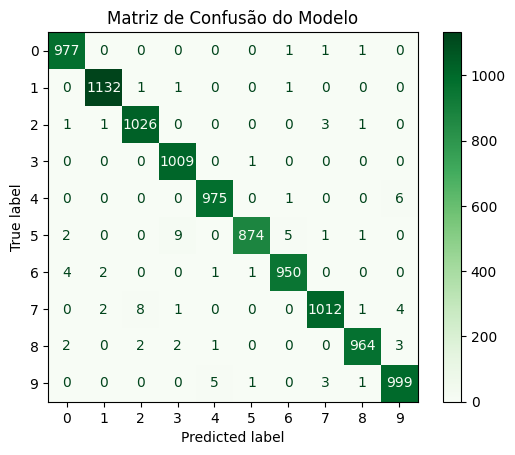

In [7]:
predicoes = modelo_cnn.predict(X_validacao_norm)
predicoes_classes = np.argmax(predicoes, axis=1)

relatorio = classification_report(y_validacao, predicoes_classes)
print("Relatório de Avaliação:")
print(relatorio)

matriz_conf = confusion_matrix(y_validacao, predicoes_classes)
exibicao = ConfusionMatrixDisplay(confusion_matrix=matriz_conf)
exibicao.plot(cmap=plt.cm.Greens)
plt.title('Matriz de Confusão do Modelo')
plt.show()